In [71]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import svm
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [72]:
data = pd.read_csv("F:\projectfinal\Datasets\diabetes_data.csv")
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,85,110,19,68,23.6,0.111,27,0
1,1,73,119,20,64,20.3,0.102,22,0
2,7,159,155,30,211,38.6,0.166,28,1
3,8,196,149,28,219,24.4,0.255,79,1
4,3,188,153,42,219,43.1,2.100,63,1


In [73]:
data = data.drop_duplicates()

In [74]:
data.shape

(2485, 9)

In [75]:

data['Outcome'].value_counts()

Outcome
1    1482
0    1003
Name: count, dtype: int64

In [76]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2485.000000,2485.000000,2485.000000,2485.000000,2485.000000,2485.000000,2485.000000,2485.000000,2485.000000
mean,3.711066,133.510664,129.184708,26.945272,167.757746,30.187243,0.913462,45.793159,0.596378
std,2.430727,43.187543,20.599531,10.271252,93.805505,8.943229,0.719439,16.640168,0.490722
min,0.000000,70.000000,90.000000,10.000000,40.000000,18.500000,0.100000,20.000000,0.000000
25%,2.000000,90.000000,111.000000,17.000000,78.000000,22.100000,0.282000,32.000000,0.000000
50%,3.000000,134.000000,133.000000,28.000000,164.000000,29.300000,0.729000,44.000000,1.000000
75%,6.000000,172.000000,147.000000,36.000000,245.000000,37.900000,1.466000,57.000000,1.000000
max,8.000000,234.000000,174.000000,44.000000,349.000000,50.000000,2.500000,85.000000,1.000000


In [77]:
df = data.drop(['SkinThickness', 'Insulin'], axis=1)

In [78]:
cols_to_nan = ['Glucose', 'BloodPressure', 'BMI']
data[cols_to_nan] = data[cols_to_nan].replace(0, np.nan)

In [79]:
df = data.drop(['SkinThickness', 'Insulin'], axis=1)

In [80]:
for col in ['Glucose', 'BloodPressure', 'BMI']:
    df[col] = df[col].fillna(df.groupby('Outcome')[col].transform('median'))

In [81]:
#  Feature Engineering: Convert DPF to Clinical 'Family History Risk
conditions = [
    (df['DiabetesPedigreeFunction'] < 0.30),
    (df['DiabetesPedigreeFunction'] >= 0.30) & (df['DiabetesPedigreeFunction'] < 0.68),
    (df['DiabetesPedigreeFunction'] >= 0.68)
]
choices = [0, 1, 2] # 0: Low Risk, 1: Medium Risk, 2: High Risk
df['Family_History_Risk'] = np.select(conditions, choices, default=1)

In [82]:
df['Family_History_Risk'].value_counts()

Family_History_Risk
2    1260
0     672
1     553
Name: count, dtype: int64

Text(0.5, 1.0, 'Family History Risk vs Diabetes Outcome')

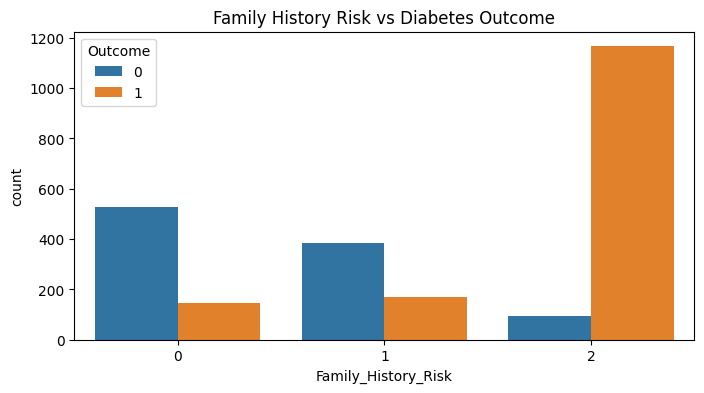

In [83]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
sns.countplot(x='Family_History_Risk', hue='Outcome', data=df)
plt.title('Family History Risk vs Diabetes Outcome')

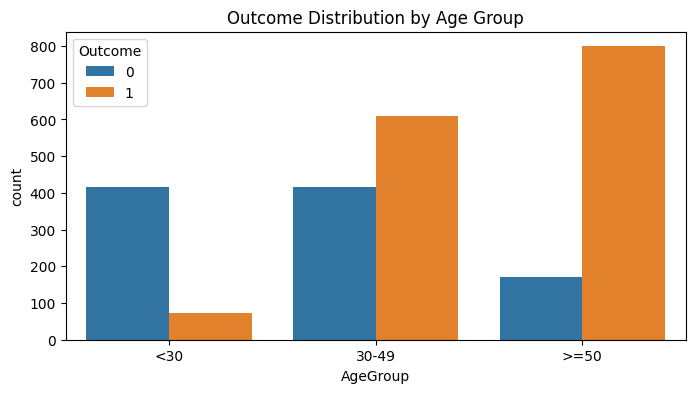

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 29, 49, 100], labels=['<30', '30-49', '>=50'])

plt.figure(figsize=(8, 4))
sns.countplot(x='AgeGroup', hue='Outcome', data=df)
plt.title("Outcome Distribution by Age Group")
plt.show()





In [85]:
df = df.drop('DiabetesPedigreeFunction', axis=1)

In [86]:
X = df[['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'Age', 'Family_History_Risk']]
y = df['Outcome']

In [87]:
print("\nFeatures used for training:", list(X.columns))


Features used for training: ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'Age', 'Family_History_Risk']


In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
print("Train Set: ", X_train.shape, y_train.shape)
print("Test Set: ", X_test.shape, y_test.shape)

Train Set:  (1988, 6) (1988,)
Test Set:  (497, 6) (497,)


In [90]:
scaler = StandardScaler()

In [91]:
cols_to_scale = ['Glucose', 'BloodPressure', 'BMI']
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [92]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=7)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, random_state=42)

In [93]:
print(accuracy_score(y_test, model.predict(X_test))*100)

96.579476861167


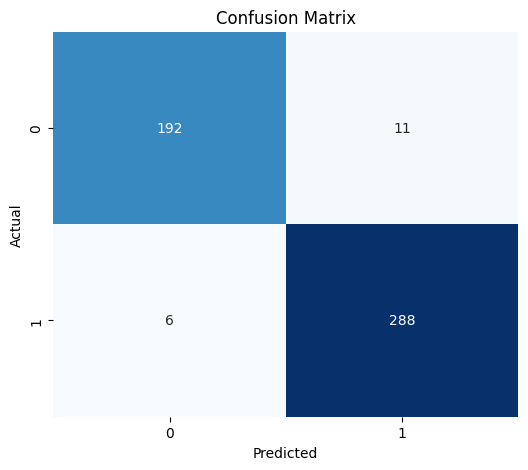


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       203
           1       0.96      0.98      0.97       294

    accuracy                           0.97       497
   macro avg       0.97      0.96      0.96       497
weighted avg       0.97      0.97      0.97       497



In [94]:
# 1. Make predictions
y_pred = model.predict(X_test)
# 2. Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [95]:
import pandas as pd

# 1. Your raw input data 
input_data = (6, 166, 72, 25.8, 51, 2)

# 2. Define your exact feature names
feature_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'Age', 'Family_History_Risk']

# 3. Convert the tuple into a Pandas DataFrame
input_df = pd.DataFrame([input_data], columns=feature_names)

# 4. --- SELECTIVE SCALING ---
# Create a copy so we don't destroy the original
scaled_input = input_df.copy()

# Specify the exact columns the scaler was trained on
cols_to_scale = ['Glucose', 'BloodPressure', 'BMI']

# ONLY transform those 3 specific columns!
scaled_input[cols_to_scale] = scaler.transform(input_df[cols_to_scale])

# 5. Make the prediction
prediction = model.predict(scaled_input)

if prediction[0] == 1:
    print("The Result is: Diabetic.")
else:
    print("The Result is: Non-Diabetic.")

The Result is: Diabetic.


Saving the trained model

In [96]:
import pickle

In [97]:
filename = 'diabetes_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [98]:
# loading the saved model
loaded_model = pickle.load(open('diabetes_model.sav', 'rb'))

In [99]:
# Save the scaler
pickle.dump(scaler, open('diabetes_scaler.sav', 'wb'))